# Sequence processing time / amortized runtime analysis

This notebook uses the `wall_seconds` already stored by `measure_energy.py` to quantify how long each method takes to process a complete dataset sequence.

Terminology used here:

- **Sequence processing time**: wall-clock time required to execute the complete method on one sequence.
- **Real-time factor (RTF)**: processing time divided by sequence duration.
- **Amortized processing time per scheduled update**: total processing time divided by the number of update slots at a chosen frequency.

The last quantity is useful as a normalized runtime estimate, but it is **not the same as causal request-to-response latency**.


In [12]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENERGY_CSV = '/data/MoveEnet_OFK_results/Energy/energy_accuracy_final_5hz_ofk/energy_measurements.csv'
OUTPUT_DIR = Path('runtime_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Frequencies at which you want to normalize the complete-sequence runtime.
NORMALIZATION_HZ = [5, 20, 50, 100, 200]

energy = pd.read_csv(ENERGY_CSV)
energy = energy[energy['status'].astype(str).str.upper() == 'OK'].copy()
energy['wall_seconds'] = pd.to_numeric(energy['wall_seconds'], errors='coerce')
energy['dataset'] = energy['dataset'].astype(str).str.lower()
energy['model'] = energy['model'].astype(str).str.lower()
energy = energy.dropna(subset=['wall_seconds'])

display(energy[['dataset','sample_id','model','wall_seconds','log_path']].head())


,dataset,sample_id,model,wall_seconds,log_path
0,h36m,H01,movenet,49.034751,/home/dberretta-iit.local/data/MoveEnet_OFK_re...
1,h36m,H01,moveenetofk,19.358793,/home/dberretta-iit.local/data/MoveEnet_OFK_re...
2,h36m,H01,openpose,400.636159,/home/dberretta-iit.local/data/MoveEnet_OFK_re...
3,h36m,H01,yolo,56.388747,/home/dberretta-iit.local/data/MoveEnet_OFK_re...
4,h36m,H01,moveenetofk,19.898308,/home/dberretta-iit.local/data/MoveEnet_OFK_re...


## Recover the dataset duration

The event-based executables print a line such as `Timestamps range from 0 to 117.547`. The cell below searches the run logs and recovers one duration for each `(dataset, sample_id)`.

If a sequence cannot be recovered automatically, fill it manually in the `MANUAL_DURATIONS` dictionary.


In [13]:
range_re = re.compile(r'Timestamps range from\s+([0-9.eE+-]+)\s+to\s+([0-9.eE+-]+)')
MANUAL_DURATIONS = {
    # ('h36m', 'H01'): 117.547,
}

def duration_from_log(path):
    try:
        text = Path(path).read_text(errors='replace')
    except Exception:
        return np.nan
    m = range_re.search(text)
    if not m:
        return np.nan
    return float(m.group(2)) - float(m.group(1))

records = []
for (dataset, sample_id), g in energy.groupby(['dataset', 'sample_id']):
    duration = MANUAL_DURATIONS.get((dataset, sample_id), np.nan)
    if not np.isfinite(duration):
        for path in g['log_path'].dropna().astype(str):
            duration = duration_from_log(path)
            if np.isfinite(duration):
                break
    records.append({'dataset': dataset, 'sample_id': sample_id, 'duration_s': duration})

durations = pd.DataFrame(records)
missing = durations[~np.isfinite(durations['duration_s'])]
if len(missing):
    print('WARNING: missing sequence durations. Add them to MANUAL_DURATIONS:')
    display(missing)
else:
    print('All sequence durations recovered.')

display(durations.head())


,dataset,sample_id,duration_s
0,dhp19,D01,NaN
1,dhp19,D02,NaN
2,dhp19,D03,NaN
3,dhp19,D04,NaN
4,dhp19,D05,NaN
5,dhp19,D06,NaN
6,dhp19,D07,NaN
7,dhp19,D08,NaN
8,dhp19,D09,NaN
9,dhp19,D10,NaN


,dataset,sample_id,duration_s
0,dhp19,D01,NaN
1,dhp19,D02,NaN
2,dhp19,D03,NaN
3,dhp19,D04,NaN
4,dhp19,D05,NaN


## Average repetitions within each sequence and compute real-time factor


In [14]:
runtime_by_sample = (
    energy.groupby(['dataset','sample_id','model'], as_index=False)
    .agg(
        processing_time_s=('wall_seconds','mean'),
        processing_time_std_s=('wall_seconds','std'),
        n_repetitions=('wall_seconds','size'),
    )
    .merge(durations, on=['dataset','sample_id'], how='left', validate='many_to_one')
)

runtime_by_sample['real_time_factor'] = runtime_by_sample['processing_time_s'] / runtime_by_sample['duration_s']
runtime_by_sample['speed_vs_realtime'] = runtime_by_sample['duration_s'] / runtime_by_sample['processing_time_s']

# For a chosen schedule f, N ≈ duration * f.
# The result is an amortized processing time per scheduled slot.
for hz in NORMALIZATION_HZ:
    n = runtime_by_sample['duration_s'] * hz
    runtime_by_sample[f'amortized_ms_at_{hz}Hz'] = 1000.0 * runtime_by_sample['processing_time_s'] / n
    runtime_by_sample[f'effective_schedule_hz_from_{hz}Hz'] = hz / runtime_by_sample['real_time_factor']

display(runtime_by_sample.head())


,dataset,sample_id,model,processing_time_s,processing_time_std_s,n_repetitions,duration_s,real_time_factor,speed_vs_realtime,amortized_ms_at_5Hz,effective_schedule_hz_from_5Hz,amortized_ms_at_20Hz,effective_schedule_hz_from_20Hz,amortized_ms_at_50Hz,effective_schedule_hz_from_50Hz,amortized_ms_at_100Hz,effective_schedule_hz_from_100Hz,amortized_ms_at_200Hz,effective_schedule_hz_from_200Hz
0,dhp19,D01,eventpointpose,32.333967,2.533588,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dhp19,D01,moveenetofk,5.568773,0.022242,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dhp19,D01,movenet,30.939833,0.443338,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dhp19,D02,eventpointpose,24.351609,1.827163,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dhp19,D02,moveenetofk,5.260679,0.025761,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Model-level summary

Interpretation of RTF:

- RTF < 1: the complete sequence is processed faster than its recorded duration.
- RTF = 1: approximately real time.
- RTF > 1: slower than real time.


In [15]:
runtime_summary = (
    runtime_by_sample.groupby(['dataset','model'], as_index=False)
    .agg(
        processing_time_mean_s=('processing_time_s','mean'),
        processing_time_std_s=('processing_time_s','std'),
        rtf_mean=('real_time_factor','mean'),
        rtf_std=('real_time_factor','std'),
        n_sequences=('sample_id','nunique'),
    )
)

display(runtime_summary.sort_values(['dataset','model']))
runtime_by_sample.to_csv(OUTPUT_DIR / 'runtime_by_sample.csv', index=False)
runtime_summary.to_csv(OUTPUT_DIR / 'runtime_summary.csv', index=False)


,dataset,model,processing_time_mean_s,processing_time_std_s,rtf_mean,rtf_std,n_sequences
0,dhp19,eventpointpose,31.088783,7.760043,NaN,NaN,12
1,dhp19,moveenetofk,5.457346,0.201596,NaN,NaN,12
2,dhp19,movenet,26.613387,4.559578,NaN,NaN,12
3,h36m,moveenetofk,11.129992,3.534722,NaN,NaN,12
4,h36m,movenet,26.411024,9.490013,NaN,NaN,12
5,h36m,openpose,177.899846,79.366263,NaN,NaN,12
6,h36m,yolo,28.789206,13.480665,NaN,NaN,12


/workspace/.projVenv/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/workspace/.projVenv/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


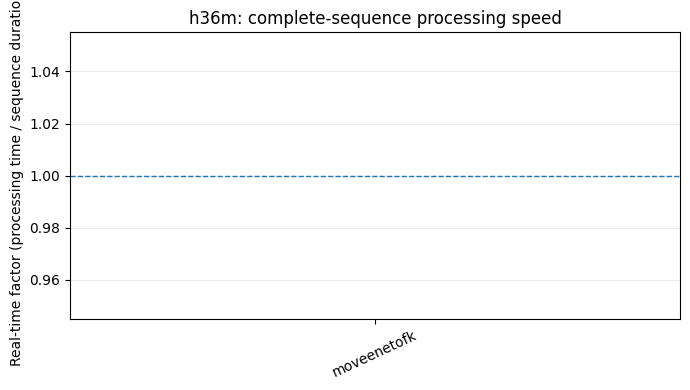

/workspace/.projVenv/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/workspace/.projVenv/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


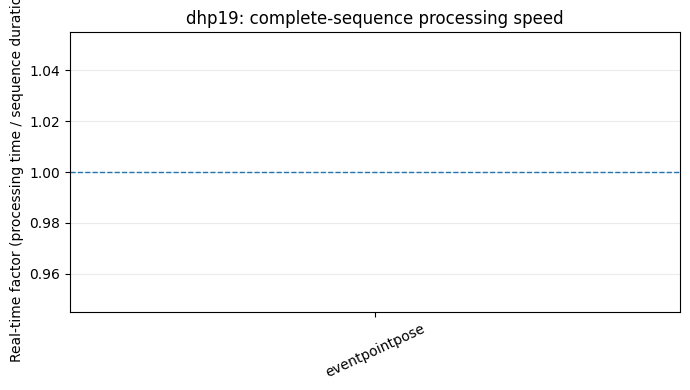

In [16]:
for dataset in ['h36m', 'dhp19']:
    d = runtime_by_sample[runtime_by_sample['dataset'] == dataset]
    if d.empty:
        continue
    means = d.groupby('model')['real_time_factor'].mean().sort_values()
    errs = d.groupby('model')['real_time_factor'].std().reindex(means.index)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(means.index, means.values, yerr=errs.values, capsize=3)
    ax.axhline(1.0, linestyle='--', linewidth=1)
    ax.set_ylabel('Real-time factor (processing time / sequence duration)')
    ax.set_title(f'{dataset}: complete-sequence processing speed')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{dataset}_real_time_factor.png', dpi=300, bbox_inches='tight')
    plt.show()
